# AR(p) Parameter Estimation

The $\text{AR}(p)$ process is defined by,

$
\begin{align}
X_t = \sum_{i=1}^p \varphi_i X_{t-i} + \varepsilon_{t}
\end{align}
\tag{1}
$

where,

$
\begin{align}
\varepsilon_t \sim \text{Normal}(0, \sigma^2)
\end{align}
\tag{2}
$

The Yule-Walker equations are relate the AR(p) parameters $\varphi_i$ to the autocorrelation function. If zero mean is</br>
assumed it follows that,

$
\begin{align}
\rho_n = \frac{\text{E}[X_t X_{t-n}]}{\text{E}[X_t^2]}
\end{align}
\tag{3}
$

The autocorrelation functions can be shown to have the following properties,

$
\begin{align}
&\rho_0 = 1 \\
&\rho_n \leq 1 \\
&\rho_n = \rho_{-n}
\end{align}
\tag{4}
$

Define the matrices,

$
\begin{align}
\hat{r} =
\begin{bmatrix}
\rho_1 \\
\rho_2 \\
\rho_3 \\
\vdots \\
\rho_{n-1} \\
\rho_{n}
\end{bmatrix}
\end{align}
\tag{5}
$

$
\begin{align}
\hat{\Phi} =
\begin{bmatrix}
\varphi_1 \\
\varphi_2 \\
\varphi_3 \\
\vdots \\
\varphi_{n-1} \\
\varphi_{n}
\end{bmatrix}
\end{align}
\tag{6}
$

$
\begin{align}
\hat{R} =
\begin{bmatrix}
1 & \rho_1 & \rho_2 & \cdots & \rho_{n-2} & \rho_{n-1} \\
\rho_1 & 1 & \rho_1 & \cdots & \rho_{n-3} & \rho_{n-2} \\
\rho_2 & \rho_1 & 1 & \cdots & \rho_{n-4} & \rho_{n-3} \\
\vdots & \vdots  & \vdots & \ddots & \vdots & \vdots \\
\rho_{n-2} & \rho_{n-3} & \rho_{n-4} & \cdots & 1 & \rho_1 \\
\rho_{n-1} & \rho_{n-2} & \rho_{n-3} & \cdots & \rho_1 & 1 \\
\end{bmatrix}
\end{align}
\tag{7}
$

Then the Yule-Walker equations are given by,

$
\begin{align}
\hat{\Phi} = \hat{R}^{-1} \hat{r}
\end{align}
\tag{8}
$

## Examples

The Yule-Walker equations for $\text{AR}(1)$ is given by,

$
\begin{align}
\varphi_1 = \rho_1
\end{align}
\tag{9}
$

This is the OLS solution.

For $\text{AR}(2)$,

$
\begin{align}
\varphi_1 &= \frac{\rho_1 - \rho_1 \rho_2}{1 - \rho_1^2} \\
\varphi_2 &= \frac{\rho_2 - \rho_1^2}{1 - \rho_1^2}
\end{align}
\tag{10}
$

## Stationaity

Stationarity of an $\text{AR}(p)$ leads to convergence of the moments as $t \to \infty$. Recall the shift operator, $L$, defined by,

$
\begin{align}
&L X_t = X_{t-1} \\
&L^2 X_t = X_{t-2} \\
&L^3 X_t = X_{t-3} \\
&\vdots
\end{align}
\tag{11}
$

An $\text{AR}(p)$ process can be written as,

$
\begin{align}
\varepsilon_t = (1 - \varphi L - \varphi^2 L^2 - \varphi^3 L^3 - \cdots - \varphi^p L^p) X_t
\end{align}
\tag{12}
$

The characteristic equation is obtained by replacing $L$ with the variable $z$ and setting the result to zero,

$
\begin{align}
1 - \varphi z - \varphi^2 z^2 - \varphi^3 z^3 - \cdots - \varphi^p z^p = 0
\end{align}
\tag{13}
$

Stationarity requires that $\lvert z \rvert > 1$. To see this consider $\text{AR}(1)$. The characteristic equation is,

$
\begin{align}
1 - \varphi z = 0
\end{align}
\tag{14}
$

The solution is $z = \frac{1}{\varphi}$. It follows that stationarity requires,

$
\begin{align}
\lvert \varphi \rvert < 1
\end{align}
\tag{15}
$

## Imports

In [1]:
%reload_ext autoreload
%autoreload 2

# import system modules and set local import path
import os
import sys
from matplotlib import pyplot

sys.path.insert(0, os.path.abspath('../../..'))

# import local modules
from lib import config
from lib.data import arima
from lib.plots import stack, fpoints, fcurve
from lib.utils import create_parameter_scan

# Config Plot Style
pyplot.style.use(config.glyfish_style)

## Helpers

In [2]:
nsample = 1000

def comparison_plot(φ_vals, title, ylim, *params):
    labels = [f"φ={val}" for val in φ_vals] 
    ylabels = r"$S_t$"
    source = lambda **kwargs : arima.create_ar_source(**kwargs)
    t, scan = create_parameter_scan(source, *params)
    stack(scan, t, ylim=ylim, title=title, labels=labels, ylabels=ylabels, xlabel="Time", figsize=(10, 6), lw=1)
    return t, scan

## Simulations

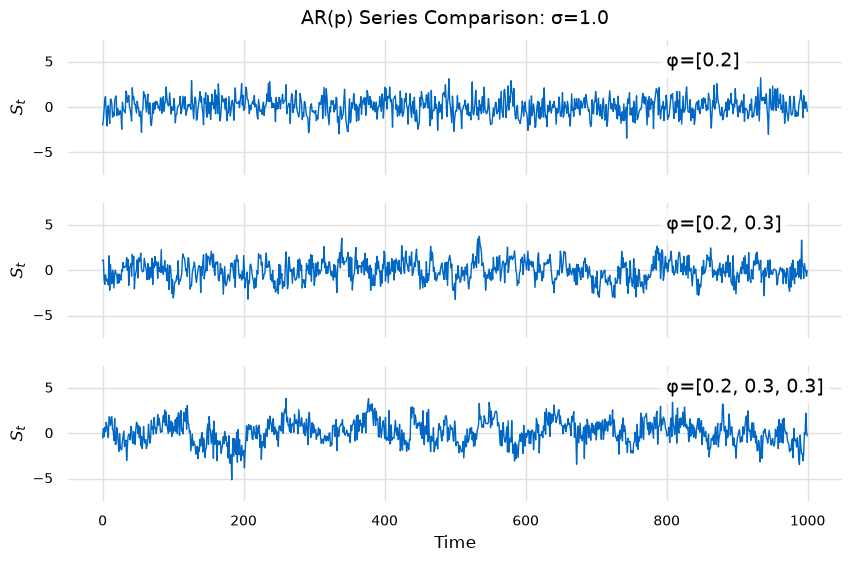

In [3]:
σ = 1.0
title = f"AR(p) Series Comparison: σ={σ}"
φ_vals = [[0.2], [0.2, 0.3], [0.2, 0.3, 0.3]]
params = [{"φ": φ, "σ": σ, "npts": nsample} for φ in φ_vals]
_, ar = comparison_plot(φ_vals, title, [-7.5, 7.5], *params)

## Estimation of $\text{AR}(p)$ Parameters ($\sigma = 1$)

$\text{AR}(p)$ parameters are estimated using two methods. The Yule-Walker ACF and `statsmodels.tsa.arima_model.ARMA`

### AR(1) Example $\varphi = 0.2$

In [4]:
arima.compute_pacf(ar[0], nlags=1)

(array([1.]), array([0.25576031]))

In [5]:
result, result_model = arima.compute_ar_estimate(ar[0], order=1)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(1, 0, 0)   Log Likelihood               -1428.346
Date:                Sun, 30 Aug 2026   AIC                           2862.692
Time:                        11:10:34   BIC                           2877.416
Sample:                             0   HQIC                          2868.288
                               - 1000                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0284      0.043      0.660      0.509      -0.056       0.113
ar.L1          0.2565      0.032      8.026      0.000       0.194       0.319
sigma2         1.0189      0.046     22.319      0.000       0.929       1.108
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 0.42
Prob(Q):                              0.96   Prob(JB):                         0.81
Heteroskedasticity (H):               1.11   Skew:                             0.05
Prob(H) (two-sided):                  0.33   Kurtosis:                         3.01
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [6]:
print(result_model.to_json(pretty=True))

{
   "est_model": "ARMA",
   "arma_est_type": "AR",
   "trend": "c",
   "const": {
      "est": 0.028413219022087967,
      "err": 0.04306807350499281,
      "est_label": "$\\hat{\\mu}$",
      "err_label": "$\\sigma_{\\hat{\\mu}}$",
      "row": 0,
      "column": 0,
      "order": 0,
      "est_id": "b0ee44f1-7a3c-4c12-8e17-2564ee508cd8",
      "param_type": "ARMA_CONST"
   },
   "order": 1,
   "params": [
      {
         "est": 0.2564798012056751,
         "err": 0.03195806629277155,
         "est_label": "$\\hat{\\phi_{0}}$",
         "err_label": "$\\sigma_{\\hat{\\phi_{0}}}$",
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "b0ee44f1-7a3c-4c12-8e17-2564ee508cd8",
         "param_type": "ARMA_PARAM"
      }
   ],
   "sigma2": {
      "est": 1.0189104742100943,
      "err": 0.04565268185354314,
      "est_label": "$\\hat{\\sigma^2}$",
      "err_label": "$\\sigma_{\\hat{\\sigma^2}}$",
      "row": 0,
      "column": 0,
      "order": 0,
      "est_

### AR(2) Example $\varphi = [0.2, 0.3]$

In [7]:
arima.compute_pacf(ar[1], nlags=2)

(array([1., 2.]), array([0.2631202, 0.3192428]))

In [8]:
result, result_model = arima.compute_ar_estimate(ar[1], order=2)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(2, 0, 0)   Log Likelihood               -1426.466
Date:                Sun, 30 Aug 2026   AIC                           2860.933
Time:                        11:10:34   BIC                           2880.564
Sample:                             0   HQIC                          2868.394
                               - 1000                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0475      0.076     -0.621      0.534      -0.197       0.102
ar.L1          0.2631      0.029      8.970      0.000       0.206       0.321
ar.L2          0.3195      0.029     10.835      0.000       0.262       0.377
sigma2         1.0148      0.046     22.118      0.000       0.925       1.105
===================================================================================
Ljung-Box (L1) (Q):                   0.12   Jarque-Bera (JB):                 0.06
Prob(Q):                              0.73   Prob(JB):                         0.97
Heteroskedasticity (H):               0.92   Skew:                            -0.00
Prob(H) (two-sided):                  0.45   Kurtosis:                         2.96
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [9]:
print(result_model.to_json(pretty=True))

{
   "est_model": "ARMA",
   "arma_est_type": "AR",
   "trend": "c",
   "const": {
      "est": -0.04749053678220483,
      "err": 0.07641291508265488,
      "est_label": "$\\hat{\\mu}$",
      "err_label": "$\\sigma_{\\hat{\\mu}}$",
      "row": 0,
      "column": 0,
      "order": 0,
      "est_id": "e360bc63-cacf-475a-af87-173c6343b049",
      "param_type": "ARMA_CONST"
   },
   "order": 2,
   "params": [
      {
         "est": 0.2630775404091602,
         "err": 0.029328106180517233,
         "est_label": "$\\hat{\\phi_{0}}$",
         "err_label": "$\\sigma_{\\hat{\\phi_{0}}}$",
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "e360bc63-cacf-475a-af87-173c6343b049",
         "param_type": "ARMA_PARAM"
      },
      {
         "est": 0.3195224370240648,
         "err": 0.029488482668243606,
         "est_label": "$\\hat{\\phi_{1}}$",
         "err_label": "$\\sigma_{\\hat{\\phi_{1}}}$",
         "row": 0,
         "column": 0,
         "order": 2,


### AR(3) Example $\varphi = [0.2, 0.3, 0.3]$

In [10]:
arima.compute_pacf(ar[2], nlags=3)

(array([1., 2., 3.]), array([0.18157843, 0.31449226, 0.27891534]))

In [11]:
result, result_model = arima.compute_ar_estimate(ar[2], order=3)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(3, 0, 0)   Log Likelihood               -1435.789
Date:                Sun, 30 Aug 2026   AIC                           2881.577
Time:                        11:10:34   BIC                           2906.116
Sample:                             0   HQIC                          2890.904
                               - 1000                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1194      0.143      0.838      0.402      -0.160       0.399
ar.L1          0.1807      0.030      5.995      0.000       0.122       0.240
ar.L2          0.3137      0.028     11.158      0.000       0.259       0.369
ar.L3          0.2793      0.031      9.092      0.000       0.219       0.340
sigma2         1.0334      0.046     22.239      0.000       0.942       1.124
===================================================================================
Ljung-Box (L1) (Q):                   0.08   Jarque-Bera (JB):                 0.08
Prob(Q):                              0.78   Prob(JB):                         0.96
Heteroskedasticity (H):               1.05   Skew:                             0.02
Prob(H) (two-sided):                  0.68   Kurtosis:                         2.98
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [12]:
print(result_model.to_json(pretty=True))

{
   "est_model": "ARMA",
   "arma_est_type": "AR",
   "trend": "c",
   "const": {
      "est": 0.1193616906367168,
      "err": 0.1425016613449519,
      "est_label": "$\\hat{\\mu}$",
      "err_label": "$\\sigma_{\\hat{\\mu}}$",
      "row": 0,
      "column": 0,
      "order": 0,
      "est_id": "e73ec922-b8a4-4e80-8557-132311f2d15d",
      "param_type": "ARMA_CONST"
   },
   "order": 3,
   "params": [
      {
         "est": 0.18074703303552916,
         "err": 0.03015103881221319,
         "est_label": "$\\hat{\\phi_{0}}$",
         "err_label": "$\\sigma_{\\hat{\\phi_{0}}}$",
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "e73ec922-b8a4-4e80-8557-132311f2d15d",
         "param_type": "ARMA_PARAM"
      },
      {
         "est": 0.3136736929640891,
         "err": 0.028113173627621044,
         "est_label": "$\\hat{\\phi_{1}}$",
         "err_label": "$\\sigma_{\\hat{\\phi_{1}}}$",
         "row": 0,
         "column": 0,
         "order": 2,
   

## Simulations $\sigma = 5.0$

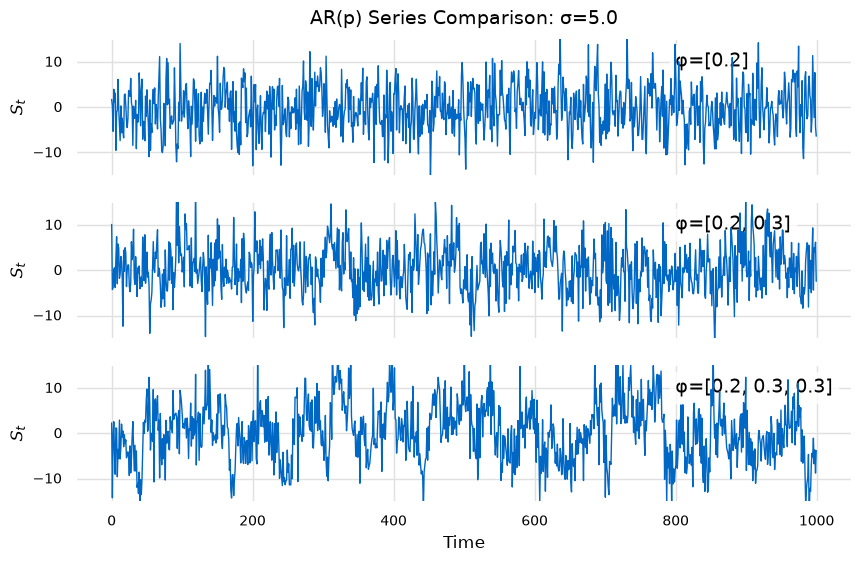

In [13]:
σ = 5.0
title = f"AR(p) Series Comparison: σ={σ}"
φ_vals = [[0.2], [0.2, 0.3], [0.2, 0.3, 0.3]]
params = [{"φ": φ, "σ": σ, "npts": nsample} for φ in φ_vals]
_, ar = comparison_plot(φ_vals, title, [-15.0, 15.0], *params)

### AR(1) Example ($\varphi = 0.2$)

In [14]:
arima.compute_pacf(ar[0], nlags=1)

(array([1.]), array([0.2219957]))

In [15]:
result, result_model = arima.compute_ar_estimate(ar[0], order=1)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(1, 0, 0)   Log Likelihood               -3020.039
Date:                Sun, 30 Aug 2026   AIC                           6046.077
Time:                        11:10:35   BIC                           6060.800
Sample:                             0   HQIC                          6051.673
                               - 1000                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.2581      0.202     -1.279      0.201      -0.653       0.137
ar.L1          0.2221      0.033      6.691      0.000       0.157       0.287
sigma2        24.5847      1.134     21.679      0.000      22.362      26.807
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 0.97
Prob(Q):                              0.96   Prob(JB):                         0.62
Heteroskedasticity (H):               1.10   Skew:                             0.05
Prob(H) (two-sided):                  0.39   Kurtosis:                         2.88
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [16]:
print(result_model.to_json(pretty=True))

{
   "est_model": "ARMA",
   "arma_est_type": "AR",
   "trend": "c",
   "const": {
      "est": -0.2580700804167659,
      "err": 0.20172988858949267,
      "est_label": "$\\hat{\\mu}$",
      "err_label": "$\\sigma_{\\hat{\\mu}}$",
      "row": 0,
      "column": 0,
      "order": 0,
      "est_id": "d97b0965-b034-4b80-848f-e5bcd9aab8ed",
      "param_type": "ARMA_CONST"
   },
   "order": 1,
   "params": [
      {
         "est": 0.22214822691296496,
         "err": 0.03319925591655866,
         "est_label": "$\\hat{\\phi_{0}}$",
         "err_label": "$\\sigma_{\\hat{\\phi_{0}}}$",
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "d97b0965-b034-4b80-848f-e5bcd9aab8ed",
         "param_type": "ARMA_PARAM"
      }
   ],
   "sigma2": {
      "est": 24.584722813491148,
      "err": 1.1340226876227384,
      "est_label": "$\\hat{\\sigma^2}$",
      "err_label": "$\\sigma_{\\hat{\\sigma^2}}$",
      "row": 0,
      "column": 0,
      "order": 0,
      "est_i

### AR(2) Example ($\varphi = [0.2, 0.3]$)

In [17]:
arima.compute_pacf(ar[1], nlags=2)

(array([1., 2.]), array([0.14824463, 0.28415559]))

In [18]:
result, result_model = arima.compute_ar_estimate(ar[1], order=2)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(2, 0, 0)   Log Likelihood               -3031.761
Date:                Sun, 30 Aug 2026   AIC                           6071.522
Time:                        11:10:35   BIC                           6091.154
Sample:                             0   HQIC                          6078.984
                               - 1000                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.3354      0.281      1.194      0.233      -0.215       0.886
ar.L1          0.1477      0.031      4.788      0.000       0.087       0.208
ar.L2          0.2849      0.031      9.302      0.000       0.225       0.345
sigma2        25.1644      1.102     22.827      0.000      23.004      27.325
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 5.09
Prob(Q):                              0.96   Prob(JB):                         0.08
Heteroskedasticity (H):               1.10   Skew:                             0.16
Prob(H) (two-sided):                  0.38   Kurtosis:                         3.13
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [19]:
print(result_model.to_json(pretty=True))

{
   "est_model": "ARMA",
   "arma_est_type": "AR",
   "trend": "c",
   "const": {
      "est": 0.33537119354426254,
      "err": 0.28092574982259,
      "est_label": "$\\hat{\\mu}$",
      "err_label": "$\\sigma_{\\hat{\\mu}}$",
      "row": 0,
      "column": 0,
      "order": 0,
      "est_id": "0366a336-1934-4ead-a1be-2ef54744c8a5",
      "param_type": "ARMA_CONST"
   },
   "order": 2,
   "params": [
      {
         "est": 0.14774780402176232,
         "err": 0.03085521461586182,
         "est_label": "$\\hat{\\phi_{0}}$",
         "err_label": "$\\sigma_{\\hat{\\phi_{0}}}$",
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "0366a336-1934-4ead-a1be-2ef54744c8a5",
         "param_type": "ARMA_PARAM"
      },
      {
         "est": 0.28492349761962643,
         "err": 0.030631956958600267,
         "est_label": "$\\hat{\\phi_{1}}$",
         "err_label": "$\\sigma_{\\hat{\\phi_{1}}}$",
         "row": 0,
         "column": 0,
         "order": 2,
   

### AR(3) Example ($\varphi = [0.2, 0.3, 0.3]$)

In [20]:
arima.compute_pacf(ar[2], nlags=3)

(array([1., 2., 3.]), array([0.22078421, 0.30289532, 0.25879962]))

In [21]:
result, result_model = arima.compute_ar_estimate(ar[1], order=3)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(3, 0, 0)   Log Likelihood               -3031.737
Date:                Sun, 30 Aug 2026   AIC                           6073.475
Time:                        11:10:35   BIC                           6098.013
Sample:                             0   HQIC                          6082.801
                               - 1000                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.3355      0.283      1.186      0.236      -0.219       0.890
ar.L1          0.1458      0.032      4.537      0.000       0.083       0.209
ar.L2          0.2839      0.031      9.110      0.000       0.223       0.345
ar.L3          0.0069      0.033      0.211      0.833      -0.058       0.072
sigma2        25.1631      1.104     22.801      0.000      23.000      27.326
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 5.14
Prob(Q):                              0.99   Prob(JB):                         0.08
Heteroskedasticity (H):               1.10   Skew:                             0.16
Prob(H) (two-sided):                  0.38   Kurtosis:                         3.13
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [22]:
print(result_model.to_json(pretty=True))

{
   "est_model": "ARMA",
   "arma_est_type": "AR",
   "trend": "c",
   "const": {
      "est": 0.3355009459600221,
      "err": 0.28290736092822794,
      "est_label": "$\\hat{\\mu}$",
      "err_label": "$\\sigma_{\\hat{\\mu}}$",
      "row": 0,
      "column": 0,
      "order": 0,
      "est_id": "a0329e1d-cd04-45c3-9920-bf73952554f9",
      "param_type": "ARMA_CONST"
   },
   "order": 3,
   "params": [
      {
         "est": 0.1457625013203993,
         "err": 0.03213055674589538,
         "est_label": "$\\hat{\\phi_{0}}$",
         "err_label": "$\\sigma_{\\hat{\\phi_{0}}}$",
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "a0329e1d-cd04-45c3-9920-bf73952554f9",
         "param_type": "ARMA_PARAM"
      },
      {
         "est": 0.28389145013716144,
         "err": 0.031163698158290037,
         "est_label": "$\\hat{\\phi_{1}}$",
         "err_label": "$\\sigma_{\\hat{\\phi_{1}}}$",
         "row": 0,
         "column": 0,
         "order": 2,
  